## Observed color and absolute magnitude distributions

Color distributions (CD) and absolute magnitude distributions (MD) are obtained for 5 populations: 
- main sequence stars (MS)
- upper MS (UMS)
- lower MS (LMS)
- giants (G)
- white dwarfs (WD)

Color-magnitude boundaries used for defining these populations are in helpers.HessConstructor. 

The full 1-kpc sample was split into 5 populations in topcat. 
From there CDs and MDs were saved. Here I load these distributions, apply smoothing, 
and normalize them. 

Note that there are two types of data source: 
- S0: full sample
- S1: subsample with additional photometric cut that removes binaries: 
  phot_rp_mean_flux_over_error>20&&phot_bp_mean_flux_over_error>20&&phot_g_mean_flux_over_error>50

In [1]:
import numpy as np
import matplotlib.pyplot as plt 
from jjmodel.tools import convolve1d_gauss

In [ ]:
# Import color and magnitude distributions for the defined populations in the modeled volume 

pops = ['wd', 'ms', 'ums', 'lms', 'g']

coldata = {pop:{'CD_S0':[],'CD_S1':[],'SCD_S0':[],'SCD_S1':[],'NSCD_S0':[],'NSCD_S1':[]} for pop in pops}
magdata = {pop:{'MD_S0':[],'MD_S1':[],'SMD_S0':[],'SMD_S1':[],'NSMD_S0':[],'NSMD_S1':[]} for pop in pops}

for pop in pops:
    cdf = np.loadtxt('./data/1kpc/coldist/cdf_' + pop + '.txt')
    coldata[pop]['CD_S0'] = cdf[:,2]
    coldata[pop]['CD_S1'] = cdf[:,3]

    mdf = np.loadtxt('./data/1kpc/magdist/mdf_' + pop + '.txt')
    magdata[pop]['MD_S0'] = mdf[:,2]
    magdata[pop]['MD_S1'] = mdf[:,3]

coldata['LOW'] = np.round(cdf[:,0],2)
coldata['HIGH'] = np.round(cdf[:,1],2)

magdata['LOW'] = np.round(mdf[:,0],2)
magdata['HIGH'] = np.round(mdf[:,1],2)

In [ ]:
# Apply smoothing 

col_smooth = 0.06        # smoothing window, mag
col_step = 0.02          # fixed in all notebooks
col_range = [-0.5, 1.65] # fixed in all notebooks

mag_smooth = 0.8         # smoothing window, mag
mag_step = 0.2           # fixed in all notebooks
mag_range = [-5, 18.5]   # fixed in all notebooks


# Smooth and normalize distributions on area
for pop in pops:
    coldata[pop]['SCD_S0'] = convolve1d_gauss(coldata[pop]['CD_S0'], col_smooth, col_range)
    coldata[pop]['SCD_S1'] = convolve1d_gauss(coldata[pop]['CD_S1'], col_smooth, col_range)
    coldata[pop]['NSCD_S0'] = coldata[pop]['SCD_S0']/(sum(coldata[pop]['SCD_S0']*col_step))
    coldata[pop]['NSCD_S1'] = coldata[pop]['SCD_S1']/(sum(coldata[pop]['SCD_S1']*col_step))

    magdata[pop]['SMD_S0'] = convolve1d_gauss(magdata[pop]['MD_S0'], mag_smooth, mag_range)
    magdata[pop]['SMD_S1'] = convolve1d_gauss(magdata[pop]['MD_S1'], mag_smooth, mag_range)
    magdata[pop]['NSMD_S0'] = magdata[pop]['SMD_S0']/(sum(magdata[pop]['SMD_S0']*mag_step))
    magdata[pop]['NSMD_S1'] = magdata[pop]['SMD_S1']/(sum(magdata[pop]['SMD_S1']*mag_step))


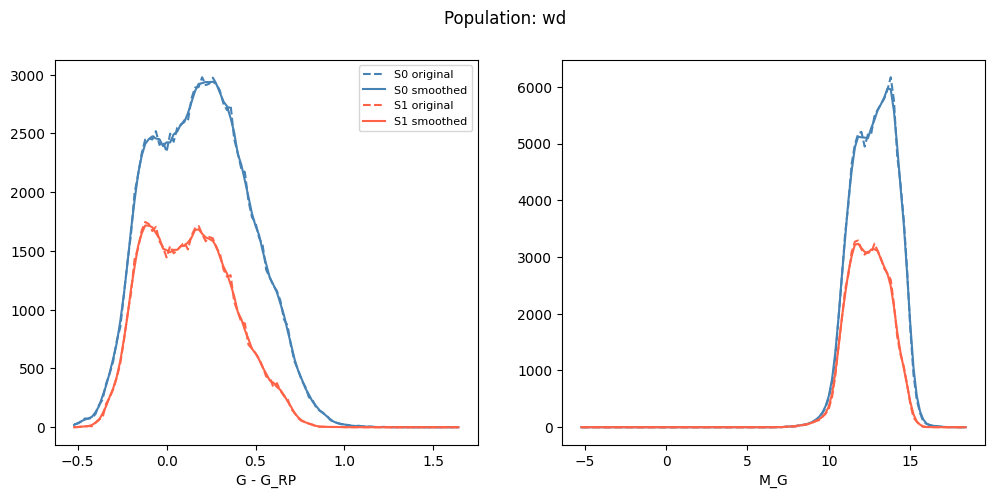

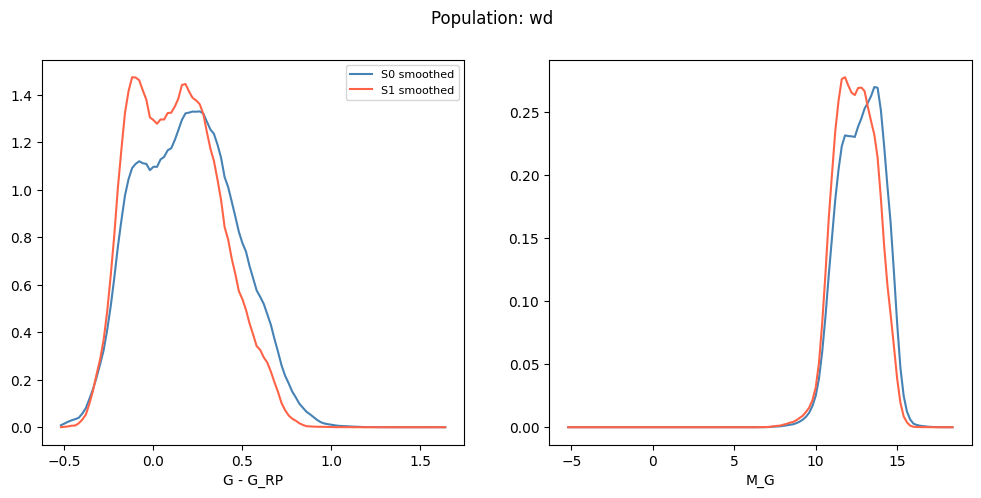

In [ ]:
# Plot populations to check the impact of smoothing

pop = 'wd'

f, ax = plt.subplots(1,2,figsize=(12,5))
ax[0].plot(coldata['LOW'], coldata[pop]['CD_S0'], label= 'S0 original', color='steelblue', linestyle='--')
ax[0].plot(coldata['LOW'], coldata[pop]['SCD_S0'], label= 'S0 smoothed', color='steelblue')
ax[0].plot(coldata['LOW'], coldata[pop]['CD_S1'], label= 'S1 original', color='tomato', linestyle='--')
ax[0].plot(coldata['LOW'], coldata[pop]['SCD_S1'], label= 'S1 smoothed', color='tomato')
ax[0].legend(loc='best', prop={'size': 8})
ax[0].set_xlabel('G - G_RP')

ax[1].plot(magdata['LOW'], magdata[pop]['MD_S0'], color='steelblue', linestyle='--')
ax[1].plot(magdata['LOW'], magdata[pop]['SMD_S0'], color='steelblue')
ax[1].plot(magdata['LOW'], magdata[pop]['MD_S1'], color='tomato', linestyle='--')
ax[1].plot(magdata['LOW'], magdata[pop]['SMD_S1'], color='tomato')
ax[1].set_xlabel('M_G')
plt.suptitle('Population: ' + pop)
f.savefig('./data/1kpc/' + pop + '_df.png')


f, ax = plt.subplots(1,2,figsize=(12,5))
ax[0].plot(coldata['LOW'], coldata[pop]['NSCD_S0'], label= 'S0 smoothed', color='steelblue')
ax[0].plot(coldata['LOW'], coldata[pop]['NSCD_S1'], label= 'S1 smoothed', color='tomato')
ax[0].legend(loc='best', prop={'size': 8})
ax[0].set_xlabel('G - G_RP')

ax[1].plot(magdata['LOW'], magdata[pop]['NSMD_S0'], color='steelblue')
ax[1].plot(magdata['LOW'], magdata[pop]['NSMD_S1'], color='tomato')
ax[1].set_xlabel('M_G')
plt.suptitle('Population: ' + pop)
f.savefig('./data/1kpc/' + pop + '_ndf.png')


In [ ]:
# Save processed tables 

for pop in pops:
    np.savetxt('./data/1kpc/coldist/nsdf_' + pop + '.txt', 
               np.column_stack((coldata['LOW'], coldata['HIGH'], 
                                coldata[pop]['SCD_S0'], coldata[pop]['SCD_S1'], 
                                coldata[pop]['NSCD_S0'], coldata[pop]['NSCD_S1'])
                                ), 
                header='LOW, HIGH, SCD_S0, SCD_S1, NCD_S0, NCD_S1'
                )
    
    np.savetxt('./data/1kpc/magdist/nsdf_' + pop + '.txt', 
               np.column_stack((magdata['LOW'], magdata['HIGH'], 
                                magdata[pop]['SMD_S0'], magdata[pop]['SMD_S1'], 
                                magdata[pop]['NSMD_S0'], magdata[pop]['NSMD_S1'])
                                ), 
                header='LOW, HIGH, SMD_S0, SMD_S1, NMD_S0, NMD_S1'
                )